# 22. Миллион строк: скорость обучения и прогноза, память, потоки

| | |
|---|---|
| **Уровень** | 4 из 4 — большие данные и сложные задачи (`4_large`) |
| **Скрипт-источник** | [`22_million_rows_speed.py`](../22_million_rows_speed.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 36 с |

**Цель.** Научиться работать с большими данными — понимать, сколько стоит обучение и прогноз и что на это влияет.

### Чему вы научитесь

- Сравнение XGBoost hist, LightGBM, sklearn HistGradientBoosting и CatBoost на 1 000 000 строк
- Экономия памяти через float32
- Скорость прогноза пакетами
- Зависимость времени от числа потоков и строк

### Данные

Синтетика — 1 000 000 объектов × 20 признаков (задача Фридмана + 15 шумовых признаков), 160 МБ в float64.

### План

1. **Этап 1.** Данные и память
2. **Этап 2.** Обучение: 300 деревьев, ~31 лист / глубина 6, темп 0.1, все ядра процессора
3. **Этап 3.** Прогноз: один большой пакет против 1000 одиночных вызовов
4. **Этап 4.** LightGBM: время обучения от числа потоков
5. **Этап 5.** LightGBM: время обучения 100 деревьев от числа строк
6. **Этап 6.** Выводы

> Ноутбук собран из `examples/4_large/22_million_rows_speed.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example

ex = Example(EXAMPLES / "4_large/22_million_rows_speed.py", title="22. Миллион строк: скорость и память",
             goal="понять, сколько стоят обучение и прогноз на больших данных")

import os
import time

import catboost as cb
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from gbcourse.style import ROLE
from sklearn.ensemble import HistGradientBoostingRegressor

## Этап 1. Данные и память

In [2]:
n = ex.size(1_000_000, 100_000)
r = np.random.default_rng(22)
X = r.uniform(0, 1, (n, 20))
y = 10 * np.sin(np.pi * X[:, 0] * X[:, 1]) + 20 * (X[:, 2] - 0.5) ** 2 + 10 * X[:, 3] + 5 * X[:, 4] + r.normal(0, 1, n)
X32 = X.astype(np.float32)
print(f"   объектов {n:_}; признаков 20; float64 — {X.nbytes / 2**20:.0f} МБ, float32 — {X32.nbytes / 2**20:.0f} МБ".replace("_", " "))
ex.note("Гистограммные бустинги всё равно переводят признаки в номера корзин (1 байт), поэтому float32 не теряет точности.")
tr, te = slice(0, int(0.9 * n)), slice(int(0.9 * n), n)
rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
threads = os.cpu_count()

   объектов 1 000 000; признаков 20; float64 — 153 МБ, float32 — 76 МБ


> ▸ **Вывод.** Гистограммные бустинги всё равно переводят признаки в номера корзин (1 байт), поэтому float32 не теряет точности.

## Этап 2. Обучение: 300 деревьев, ~31 лист / глубина 6, темп 0.1, все ядра процессора

In [3]:
print(f"   потоков: {threads}")
models = {
    "XGBoost hist": xgb.XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, tree_method="hist", n_jobs=threads),
    "LightGBM": lgb.LGBMRegressor(n_estimators=300, learning_rate=0.1, num_leaves=31, verbose=-1, n_jobs=threads),
    "sklearn HistGB": HistGradientBoostingRegressor(max_iter=300, learning_rate=0.1, max_leaf_nodes=31, early_stopping=False),
    "CatBoost": cb.CatBoostRegressor(iterations=300, learning_rate=0.1, depth=6, verbose=0, thread_count=threads, allow_writing_files=False),
}
fit_time = {}
for name, m in models.items():
    t = time.perf_counter()
    m.fit(X32[tr], y[tr])
    fit_time[name] = time.perf_counter() - t
    print(f"   {name:15s} обучение {fit_time[name]:6.2f} с; RMSE на тесте {rmse(y[te], m.predict(X32[te])):.3f} (шум σ = 1)")

   потоков: 20


   XGBoost hist    обучение   2.81 с; RMSE на тесте 1.030 (шум σ = 1)


   LightGBM        обучение   1.70 с; RMSE на тесте 1.035 (шум σ = 1)


   sklearn HistGB  обучение   2.99 с; RMSE на тесте 1.036 (шум σ = 1)


   CatBoost        обучение   5.74 с; RMSE на тесте 1.013 (шум σ = 1)


## Этап 3. Прогноз: один большой пакет против 1000 одиночных вызовов

In [4]:
Xq = X32[te][:100_000]
print(f"   пакет: {len(Xq):_} объектов".replace("_", " "))
for name in ("XGBoost hist", "LightGBM"):
    m = models[name]
    t = time.perf_counter()
    m.predict(Xq)
    batch = time.perf_counter() - t
    t = time.perf_counter()
    for i in range(1000):
        m.predict(Xq[i:i + 1])
    single = (time.perf_counter() - t) / 1000
    print(f"   {name:13s} пакет: {len(Xq) / batch:_.0f} объектов/с ({batch / len(Xq) * 1e6:.2f} мкс на объект); "
          f"одиночный вызов: {single * 1e6:.0f} мкс".replace("_", " "))
ex.note("Одиночный вызов тратит почти всё время на накладные расходы Python — прогнозируйте пакетами.")

   пакет: 100 000 объектов
   XGBoost hist  пакет: 6 239 432 объектов/с (0.16 мкс на объект); одиночный вызов: 164 мкс


   LightGBM      пакет: 1 743 272 объектов/с (0.57 мкс на объект); одиночный вызов: 228 мкс


> ▸ **Вывод.** Одиночный вызов тратит почти всё время на накладные расходы Python — прогнозируйте пакетами.

## Этап 4. LightGBM: время обучения от числа потоков

   потоков  1:   8.33 с (ускорение ×1.0)


   потоков  2:   4.79 с (ускорение ×1.7)


   потоков  4:   2.54 с (ускорение ×3.3)


   потоков  8:   1.37 с (ускорение ×6.1)


   потоков 20:   0.85 с (ускорение ×9.8)


> ▸ **Вывод.** Рост ускорения замедляется: часть работы последовательна, а потоки делят память.

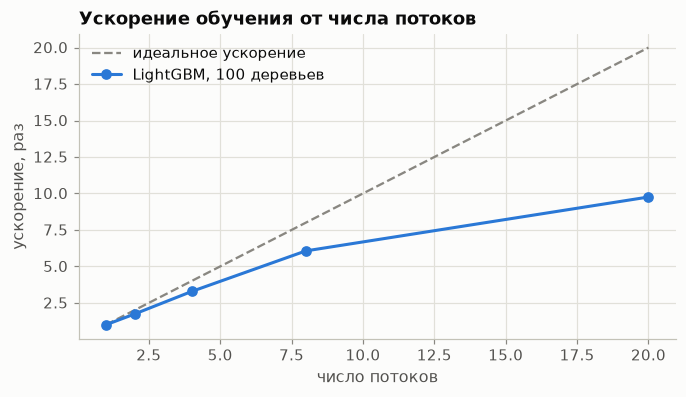

In [5]:
base, speed = None, []
for k in sorted({1, 2, 4, 8, threads}):
    if k > threads:
        continue
    t = time.perf_counter()
    lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, num_leaves=31, verbose=-1, n_jobs=k).fit(X32[tr], y[tr])
    sec = time.perf_counter() - t
    base = base or sec
    print(f"   потоков {k:2d}: {sec:6.2f} с (ускорение ×{base / sec:.1f})")
    speed.append((k, base / sec))
ex.note("Рост ускорения замедляется: часть работы последовательна, а потоки делят память.")
fig, ax = plt.subplots(figsize=(7, 3.6))
ks = [k for k, _ in speed]
ax.plot(ks, ks, color=ROLE["truth"], ls="--", lw=1.5, label="идеальное ускорение")
ax.plot(ks, [s for _, s in speed], "o-", color=ROLE["model"], lw=2, ms=6, label="LightGBM, 100 деревьев")
ax.set(xlabel="число потоков", ylabel="ускорение, раз", title="Ускорение обучения от числа потоков")
ax.legend()
ex.finish(fig, "22_threads")

## Этап 5. LightGBM: время обучения 100 деревьев от числа строк

In [6]:
for m_ in (n // 100, n // 10, n):
    t = time.perf_counter()
    lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, num_leaves=31, verbose=-1, n_jobs=threads).fit(X32[:m_], y[:m_])
    print(f"   {m_:>9_} строк: {time.perf_counter() - t:6.2f} с".replace("_", " "))

      10 000 строк:   0.05 с


     100 000 строк:   0.17 с


   1 000 000 строк:   0.96 с


## Этап 6. Выводы

   быстрее всего на этих данных обучился: LightGBM (1.70 с)


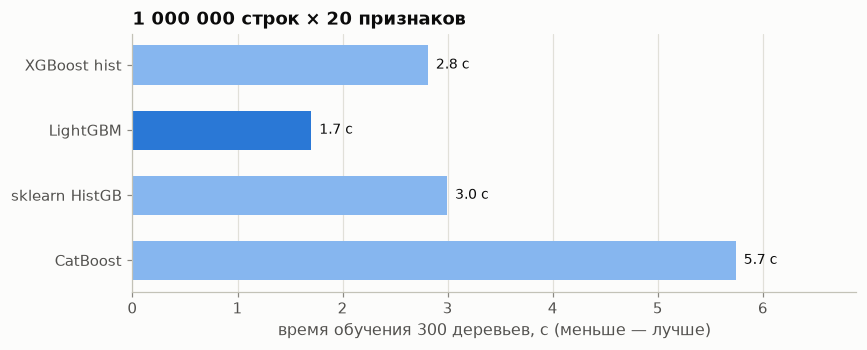

> ▸ **Вывод.** На миллионе числовых строк все четыре библиотеки обучают 300 деревьев за несколько секунд (здесь 2–7 с). Время растёт медленнее числа строк: на малых данных доминируют накладные расходы, на больших — проход по данным. Храните признаки в float32, прогнозируйте пакетами, используйте все ядра.

Готово за 34.2 с


In [7]:
fastest = min(fit_time, key=fit_time.get)
print(f"   быстрее всего на этих данных обучился: {fastest} ({fit_time[fastest]:.2f} с)")
ex.barh(fit_time, best=fastest, name="22_fit_time", fmt="{:.1f} с",
        xlabel="время обучения 300 деревьев, с (меньше — лучше)", title=f"{n:_} строк × 20 признаков".replace("_", " "))
ex.note("""На миллионе числовых строк все четыре библиотеки обучают 300 деревьев за несколько секунд (здесь 2–7 с).
Время растёт медленнее числа строк: на малых данных доминируют накладные расходы, на больших — проход по данным.
Храните признаки в float32, прогнозируйте пакетами, используйте все ядра.""")
ex.done()

## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Сравните время обучения на float64 и float32.
2. Меняйте `max_bin` у LightGBM (63, 255, 1023) — как меняются время и RMSE?
3. Если есть видеокарта, запустите XGBoost с `device="cuda"` и сравните время.

## Что дальше

- **Теория в курсе:** [8.3 «Поиск разбиений»](../../../lessons/lesson_8_3/README.md), [9.4 «Сравнение»](../../../lessons/lesson_9_4/README.md), [13.3 «Эксплуатация»](../../../lessons/lesson_13_3/README.md).
- **Предыдущий пример:** [21. Картинки рукописных цифр (1797 × 64 пикселя): где бустинг — не лучший выбор](../../3_medium/notebooks/21_digits_images.ipynb)
- **Следующий пример:** [23. Прогноз продаж: 50 магазинов × 2 года, признаки из прошлого и разбиение по времени](23_time_series_forecasting.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)